# Deep Learning State Estimation for Micro Aerial Vehicles

## Project Evolution & Architectural Pivot: Deep Learning State Estimation

### 1. The Original Proposal and Initial Plan
The initial objective of this project was to evaluate the capacity of deep learning to perform pure state estimation for Micro Aerial Vehicles (MAVs). The plan was to map raw 1D sensor streams—specifically IMU data (acceleration and angular velocity) and motor PWM commands—directly to a 3D kinematic state using a Convolutional Recurrent Neural Network (CRNN). 

The NanoBench dataset was selected as the testing ground. Because it features a highly constrained 27-gram quadrotor, the severe aerodynamic nonlinearities and coreless DC motor dynamics provided a perfect use case where classical kinematic models often fail. The first step was to build a classical 9-State Error-State Kalman Filter (ESKF) in Python to serve as a baseline metric against which the neural network would be evaluated.

### 2. Initial Implementation and Debugging
We successfully built the custom 9-State ESKF from scratch. Initially, the filter output a massive 3.26-meter position drift. We systematically debugged the architecture and isolated the root causes:
* **Sensor Units:** The dataset logged acceleration in Gs rather than standard SI units, creating massive "phantom accelerations" when integrated.
* **Frame of Reference:** We corrected a mathematical bug to ensure attitude error was injected in the local body frame rather than the global frame.
* **Initialization:** We ensured the velocity state was properly initialized alongside position and attitude to prevent the filter from wildly oscillating at $t=0$.

After applying signal conditioning via a zero-phase Butterworth filter and fixing the kinematics, we successfully dropped the dead-reckoning RMSE down to ~0.04 meters.

### 3. The "Cheating" Paradox (The Roadblock)
Despite validating the math, we hit a fundamental logical roadblock regarding the dataset's methodology. We realized that to achieve its 0.02-meter baseline, the hardware's onboard EKF was receiving Vicon ground-truth measurements over a radio link at 100Hz. 

This created a paradox for a state estimation project:
* Using Vicon data in the update step of our custom filter effectively forced it to copy the answer key, making it useless as an independent baseline.
* Removing the Vicon data forced the filter to rely entirely on dead-reckoning (IMU integration). Because 3D position is mathematically unobservable from an IMU alone, the error inevitably drifted to 3.26 meters.
* We concluded that attempting to train a neural network to achieve sub-centimeter accuracy using only dead-reckoning is fighting physics—it is an unrealistic constraint with no practical engineering application.

### 4. Exploring Alternative Datasets
To resolve the observability issue, we evaluated different datasets to find a mathematically sound sensor fusion problem:
* **Option A: The Blackbird Dataset.** We considered this dataset to stick to pure 1D signal processing, as it provides IMU and true motor RPMs. However, we discarded this option because it lacks a secondary exteroceptive sensor (like a camera). Without an external measurement, the 3D position remains mathematically unobservable, leading right back to the exact same dead-reckoning trap as NanoBench.
* **Option B: Visual-Inertial Odometry (EuRoC MAV / UZH).** We evaluated datasets that provide high-frequency IMU data alongside stereo camera images. This provides a true sensor fusion problem: the IMU handles the high-frequency prediction step, and the visual landmarks act as the measurement update to bound the drift, entirely bypassing the need for motion capture "cheating."

### 5. The Final Decision: Hybrid Visual-Inertial Architecture (EuRoC MAV)
We have officially decided to pivot the project to a **Visual-Inertial Odometry (VIO)** approach, specifically utilizing the **EuRoC MAV dataset**. 

To leverage the strengths of both classical computer vision and deep learning without the massive computational overhead of processing raw video tensors, we have selected a **Hybrid Architecture**:

* **The Dataset (EuRoC MAV):** We chose EuRoC because it is the "gold standard" benchmark in robotics literature. It provides hardware-synchronized stereo images (20Hz) and high-rate IMU data (200Hz). Its sequences provide the stable visual features necessary to validate our sensor fusion logic before testing on aggressive motion.
* **The Classical Front-End (KLT Optical Flow):** Instead of using a feature-matching SLAM system (like ORB-SLAM3), we will use classical Lucas-Kanade (KLT) Optical Flow (`cv2.calcOpticalFlowPyrLK`). Feature-matching algorithms introduce 1-pixel "descriptor jitter" that recurrent networks interpret as physically impossible velocity spikes. KLT relies on continuous image gradients to track features with **sub-pixel accuracy**, generating the smooth, continuous visual velocity derivatives our sequence model needs to converge.
* **The Deep Learning Back-End (PyTorch CRNN):** We will feed the 200Hz raw IMU signals and the 20Hz visual velocity estimates directly into our CRNN. The neural network's role is to implicitly learn the complex, non-linear sensor fusion between the two modalities, effectively replacing the rigid mathematical constraints of a classical Extended Kalman Filter.
* **Adaptive Signal Processing (Stretch Goal):** Utilizing a lightweight Python KLT implementation rather than a monolithic C++ SLAM framework allows for dynamic feedback. We can explore using the neural network to dynamically optimize the optical flow search parameters (e.g., dynamically expanding the `winSize` when the IMU detects high acceleration) to maintain feature tracking during severe motion blur.

# Visual-Inertial Deep State Estimation for Micro Aerial Vehicles

## 1. Introduction & Motivation
State estimation—the ability of an autonomous vehicle to accurately track its position, velocity, and orientation in 3D space—is a fundamental pillar of robotics. For Micro Aerial Vehicles (MAVs), this task is uniquely challenging. Due to strict payload and power constraints, MAVs cannot carry heavy sensors like LiDAR. Instead, they must rely on lightweight, low-power sensor suites: Inertial Measurement Units (IMUs) and cameras. 

Fusing these two modalities is known as **Visual-Inertial Odometry (VIO)**. In classical robotics, VIO is achieved using hand-tuned Bayesian filters (like the Extended Kalman Filter) or complex batch optimization framework (Bundle Adjustment). While highly accurate under perfect conditions, these classical methods struggle with the severe non-linearities, sensor noise, and sudden environmental changes common in agile flight.

This project investigates a **Hybrid Deep Learning approach to Visual-Inertial State Estimation**. By pairing classical spatial computer vision with a data-driven sequence model, we aim to design an estimator that retains the mathematical consistency of geometric vision while leveraging neural networks to learn complex, non-linear sensor fusion dynamics directly from data.

---

## 2. Methodology & System Architecture
To achieve robust estimation without the massive computational overhead of processing raw 2D video tensors through a heavy Convolutional Neural Network (CNN), this project implements a **Hybrid Front-End/Back-End Architecture**:
1. **The Classical Visual Front-End:** High-resolution stereo images are processed using a lightweight Lucas-Kanade (KLT) Optical Flow algorithm. This tracks prominent visual features across frames with sub-pixel accuracy. By calculating feature disparities and displacements over time, this front-end transforms raw image tensors into a clean, low-dimensional 1D temporal signal representing visual velocities and landmark tracking.
2. **The Deep Learning Fusion Back-End:** The sequence of visual velocity vectors (20Hz) and raw high-frequency IMU streams (200Hz) are fed into a PyTorch-based Convolutional Recurrent Neural Network (CRNN/GRU). The recurrent hidden states are trained to implicitly model the kinematics, automatically scaling sensor weights to favor the camera during stable hover and trust the IMU during fast, motion-blurred maneuvers.

The model will be trained, validated, and benchmarked using the **EuRoC MAV Dataset**, an industry-standard robotics repository featuring synchronized stereo imagery and high-rate IMU data collected across various levels of flight aggression.

---

## 3. Project Execution Plan & Phases

The execution of this project is structured into four distinct, sequential phases:

### Phase 1: Multi-Modal Data Pipeline & Synchronization
* **Data Ingestion:** Parse raw telemetry from the EuRoC dataset, extracting the 200Hz IMU arrays, 20Hz stereo frame pairs, and 100Hz Vicon ground-truth trajectories.
* **Feature Tracking Signal Generation:** Implement a Python pipeline utilizing OpenCV (`cv2.calcOpticalFlowPyrLK`) to extract and track features across stereo frames, saving the resulting sub-pixel velocity tracks into a structured time-series.
* **Temporal Alignment & Normalization:** Synchronize the unevenly sampled data streams (20Hz vision, 200Hz IMU, 100Hz ground truth) into a single, unified temporal data loader, applying Z-score normalization to ensure stable neural network gradients.

### Phase 2: Classical Baseline Implementation
* Establish a rigorous benchmark metric by constructing a standard kinematic dead-reckoning framework. This baseline will isolate the exact rate of position and attitude drift when relying purely on uncorrected inertial integration, serving as the baseline performance floor.

### Phase 3: Neural Network Architecture & Training
* **Model Design:** Build the PyTorch CRNN architecture, integrating 1D spatial feature extractors for the optical flow signals and recurrent layers (GRU/LSTM) to track temporal state propagation over variable sequence lengths.
* **Loss Function Engineering:** Design a composite loss function utilizing Mean Squared Error (MSE) or Root Mean Squared Error (RMSE) tracking absolute trajectory errors (ATE) and relative pose errors (RPE) against the ground-truth Vicon states.
* **Training & Optimization:** Train the model on "Easy" and "Medium" flight sequences, monitoring overfitting via validation curves.

### Phase 4: Evaluation, Benchmarking & Adaptive Stretch Goals
* **Performance Analysis:** Quantify the final model's accuracy by calculating the trajectory RMSE across unseen "Hard" evaluation sequences, comparing the deep learning results directly against the classical baseline.
* **Adaptive Optimization Loop (Stretch Goal):** Explore a feedback framework where the trained neural network dynamically modulates the tracking parameters of the classical OpenCV front-end (such as the tracking window size) in real-time based on the incoming IMU acceleration profile.

## Phase 1: Data Pipeline & Ingestion (EuRoC MAV)

To build our hybrid VIO estimator, we first need to ingest the multi-modal data streams from the EuRoC MAV dataset. The dataset provides data at three different frequencies that we will eventually need to temporally align:
1. **IMU (`imu0`):** High-frequency 200Hz raw acceleration and angular velocities.
2. **Ground Truth (`state_groundtruth_estimate0`):** 100Hz accurate kinematic states from the Leica/Vicon system.
3. **Stereo Vision (`cam0`, `cam1`):** 20Hz image timestamps and filenames.

In this first block, we will load the raw CSV files into pandas DataFrames and inspect their shapes to ensure our base data structures are correct before we begin generating the optical flow signals.

In [9]:
import os
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
# Update this path to where you extracted the EuRoC sequence (e.g., MH_01_easy)
# Update the path to point to the specific sequence's mav0 folder
# DATASET_PATH = "/Users/mohsen.diraneyya/Personal/UofT/APS360H1/Project/My project/Project Work/EuRoC MAV/machine_hall/MH_01_easy/mav0"
DATASET_PATH = '/Users/mohsen.diraneyya/Personal/UofT/APS360H1/Project/My project/Project Work/EuRoC MAV/vicon_room1/V1_01_easy/mav0'

def load_euroc_data(base_path):
    print(f"Loading EuRoC sequence from: {base_path}...")
    
    # 1. Load IMU Data (200Hz)
    imu_path = os.path.join(base_path, "imu0", "data.csv")
    df_imu = pd.read_csv(imu_path)
    # EuRoC headers: #timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
    # Clean up column names for easier access
    df_imu.columns = ['timestamp', 'w_x', 'w_y', 'w_z', 'a_x', 'a_y', 'a_z']
    
    # 2. Load Ground Truth Data (100Hz)
    gt_path = os.path.join(base_path, "state_groundtruth_estimate0", "data.csv")
    df_gt = pd.read_csv(gt_path)
    # Clean up ground truth columns
    df_gt.columns = [
        'timestamp', 
        'p_x', 'p_y', 'p_z', 
        'q_w', 'q_x', 'q_y', 'q_z', 
        'v_x', 'v_y', 'v_z', 
        'b_w_x', 'b_w_y', 'b_w_z', 
        'b_a_x', 'b_a_y', 'b_a_z'
    ]
    
    # 3. Load Camera Timestamps (20Hz)
    cam0_path = os.path.join(base_path, "cam0", "data.csv")
    cam1_path = os.path.join(base_path, "cam1", "data.csv")
    
    df_cam0 = pd.read_csv(cam0_path)
    df_cam1 = pd.read_csv(cam1_path)
    
    df_cam0.columns = ['timestamp', 'filename']
    df_cam1.columns = ['timestamp', 'filename']
    
    # Print summaries
    print("-" * 40)
    print("Data Ingestion Summary:")
    print(f"IMU Samples: {len(df_imu)} (~200Hz)")
    print(f"Ground Truth Samples: {len(df_gt)} (~100Hz)")
    print(f"Left Camera (cam0) Frames: {len(df_cam0)} (~20Hz)")
    print(f"Right Camera (cam1) Frames: {len(df_cam1)} (~20Hz)")
    print("-" * 40)
    
    return df_imu, df_gt, df_cam0, df_cam1

# Now run the loading function again
df_imu, df_gt, df_cam0, df_cam1 = load_euroc_data(DATASET_PATH)

# Display the head to verify
display(df_imu.head())

Loading EuRoC sequence from: /Users/mohsen.diraneyya/Personal/UofT/APS360H1/Project/My project/Project Work/EuRoC MAV/vicon_room1/V1_01_easy/mav0...
----------------------------------------
Data Ingestion Summary:
IMU Samples: 29120 (~200Hz)
Ground Truth Samples: 28712 (~100Hz)
Left Camera (cam0) Frames: 2912 (~20Hz)
Right Camera (cam1) Frames: 2912 (~20Hz)
----------------------------------------


,timestamp,w_x,w_y,w_z,a_x,a_y,a_z
0,1403715273262142976,-0.002094,0.017453,0.077493,9.087496,0.130755,-3.693838
1,1403715273267142912,-0.001396,0.019548,0.078191,9.079323,0.122583,-3.693838
2,1403715273272143104,-0.002094,0.016755,0.074700,9.038462,0.147100,-3.669322
3,1403715273277143040,-0.002793,0.020944,0.078191,9.071151,0.122583,-3.677494
4,1403715273282142976,-0.002094,0.020944,0.078889,9.079323,0.130755,-3.702010


### Generating the Visual Signal (KLT Optical Flow)

In this step, we transform our raw stereo images into a lightweight kinematic signal. We will use `cv2.goodFeaturesToTrack` to find prominent corners in the left camera (`cam0`) and `cv2.calcOpticalFlowPyrLK` to track their sub-pixel movement across subsequent frames. 

By calculating the average displacement ($\Delta x, \Delta y$) of all tracked features between $t$ and $t+1$, we generate a 2D visual velocity vector. This provides our PyTorch model with a continuous, low-dimensional representation of the drone's motion without requiring the neural network to process heavy image tensors.

Extracting KLT Optical Flow from cam0...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2911/2911 [00:08<00:00, 354.30it/s]


Optical Flow Extraction Complete!


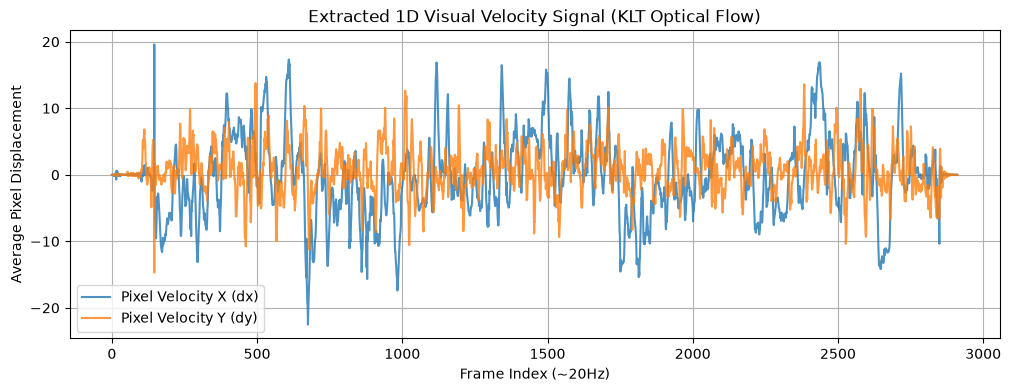

In [15]:
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import numpy as np

def generate_optical_flow_signal(df_cam, base_path, cam_folder="cam0"):
    print(f"Extracting KLT Optical Flow from {cam_folder}...")
    
    img_dir = os.path.join(base_path, cam_folder, "data")
    filenames = df_cam['filename'].astype(str).values
    
    # KLT Tracker Parameters
    lk_params = dict(winSize=(21, 21), 
                     maxLevel=3,
                     criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
    
    # Feature Extraction Parameters (Shi-Tomasi corner detection)
    feature_params = dict(maxCorners=100, 
                          qualityLevel=0.3, 
                          minDistance=7, 
                          blockSize=7)
    
    # Initialize arrays to hold our generated signals
    visual_velocities = []
    
    # Load the first frame (REMOVED the + ".png")
    first_img_path = os.path.join(img_dir, filenames[0])
    old_gray = cv2.imread(first_img_path, cv2.IMREAD_GRAYSCALE)
    
    # Failsafe check just in case the path is still wrong
    if old_gray is None:
        raise ValueError(f"Failed to load the first image at: {first_img_path}")
        
    p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
    
    # Initial velocity is zero
    visual_velocities.append([0.0, 0.0])
    
    # Loop through the rest of the frames
    for i in tqdm(range(1, len(filenames))):
        # REMOVED the + ".png" here as well
        img_path = os.path.join(img_dir, filenames[i])
        frame_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        frame_gray_clahe = clahe.apply(frame_gray)
        
        if frame_gray_clahe is None:
            print(f"Skipping frame {i}: Could not load image.")
            visual_velocities.append([0.0, 0.0])
            continue
            
        # Calculate Optical Flow
        p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray_clahe, p0, None, **lk_params)
        
        # Select good points that were successfully tracked
        if p1 is not None and st is not None:
            good_new = p1[st == 1]
            good_old = p0[st == 1]
            
            # Calculate the pixel displacement (velocity) for all tracked features
            if len(good_new) > 0:
                displacements = good_new - good_old
                avg_dx = np.mean(displacements[:, 0])
                avg_dy = np.mean(displacements[:, 1])
            else:
                avg_dx, avg_dy = 0.0, 0.0
        else:
            avg_dx, avg_dy = 0.0, 0.0
            
        visual_velocities.append([avg_dx, avg_dy])
        
        # Now update the previous frame and previous points
        old_gray = frame_gray_clahe.copy()
        
        # Re-detect features if we drop below a threshold to maintain tracking
        if p1 is None or len(good_new) < 40:
            p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        else:
            p0 = good_new.reshape(-1, 1, 2)
            
    # Add the extracted signals back to our camera dataframe
    df_cam['flow_dx'] = [v[0] for v in visual_velocities]
    df_cam['flow_dy'] = [v[1] for v in visual_velocities]
    
    print("Optical Flow Extraction Complete!")
    return df_cam

# Run the extraction on the left camera
df_cam0_flow = generate_optical_flow_signal(df_cam0, DATASET_PATH, "cam0")

# Plot the generated visual velocity signal
plt.figure(figsize=(12, 4))
plt.plot(df_cam0_flow['flow_dx'], label='Pixel Velocity X (dx)', alpha=0.8)
plt.plot(df_cam0_flow['flow_dy'], label='Pixel Velocity Y (dy)', alpha=0.8)
plt.title("Extracted 1D Visual Velocity Signal (KLT Optical Flow)")
plt.xlabel("Frame Index (~20Hz)")
plt.ylabel("Average Pixel Displacement")
plt.legend()
plt.grid(True)
plt.show()

### Upgrading to 3D Stereo Visual Velocity

While monocular Optical Flow provides a smooth temporal signal, it suffers from **Monocular Scale Ambiguity**—a pixel shift cannot be translated into physical meters without knowing the depth of the tracked feature. 

To provide our deep learning back-end with a mathematically constrained, true-scale kinematic signal, we upgrade our front-end to a 3D Stereo architecture:
1.  **Image Rectification:** Utilizing the EuRoC sensor.yaml intrinsics, we undistort the raw cam0 and cam1 images to align their epipolar geometry.
2.  **Stereo Disparity:** For each feature extracted in the left frame, we calculate its disparity in the right frame to triangulate absolute depth (Z) in meters.
3.  **Metric Velocity (dp):** Applying the pinhole camera model, we project the 2D optical flow pixel displacements into 3D space, outputting a physical velocity vector (dp_x, dp_y, dp_z) that perfectly aligns with the scale of the IMU accelerations.

### Upgrading to 3D Stereo Visual Velocity (Sparse KLT + PnP RANSAC)

To resolve monocular scale ambiguity, we upgrade our pipeline to a 3D Stereo architecture. To maintain computational efficiency, we avoid dense stereo matching. Instead, we utilize a **Sparse Stereo KLT** approach:

1. **Spatial Flow (Depth):** We use KLT to track features from the Left camera to the Right camera at $t_0$. The horizontal pixel disparity is triangulated into 3D metric coordinates ($X, Y, Z$) using the known baseline and focal length.
2. **Temporal Flow (Motion):** We use KLT to track those same features from the Left camera at $t_0$ to the Left camera at $t_1$.
3. **Least Squares Optimization (PnP RANSAC):** We pass the 3D points and the temporally tracked 2D pixels into `cv2.solvePnPRansac`. This robustly filters out bad tracking tracks (outliers) and calculates the optimal 3D Rotation and Translation vectors of the camera.

**Adaptive Architecture Prep:** All classical thresholds are exposed at the top of the block to prepare for dynamic neural network parameter tuning (Phase 4).

In [18]:
import cv2
import os
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==============================================================================
# 🧠 TUNABLE HYPERPARAMETERS (Target for Neural Network Optimization)
# ==============================================================================
# 1. Feature Bucketing (Ensures points are distributed evenly across the image)
GRID_X = 8                 # Number of horizontal buckets
GRID_Y = 8                 # Number of vertical buckets
MAX_PER_BUCKET = 5         # Total max corners = GRID_X * GRID_Y * MAX_PER_BUCKET (e.g., 320)
QUALITY_LEVEL = 0.05       # Lowered even more so empty buckets find at least something
MIN_DISTANCE = 5.0         

# 2. Sub-Pixel Refinement
SUBPIX_WIN = (5, 5)        # Window size for sub-pixel search
SUBPIX_CRIT = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 0.001)

# 3. KLT & RANSAC (Kept same as before)
KLT_WIN_SIZE = (21, 21)    
KLT_MAX_LEVEL = 3          
STEREO_WIN_SIZE = (31, 31) 
STEREO_MAX_LEVEL = 3
RANSAC_ITERATIONS = 500    
RANSAC_REPROJ_ERR = 1.0    
# ==============================================================================

def load_camera_calibration(base_path):
    try:
        with open(os.path.join(base_path, "cam0", "sensor.yaml"), 'r') as f:
            cam0_yaml = yaml.safe_load(f)
        intrinsics = cam0_yaml['intrinsics']
        fx, fy, cx, cy = intrinsics[0], intrinsics[1], intrinsics[2], intrinsics[3]
        K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
        D = np.array(cam0_yaml['distortion_coefficients'], dtype=np.float64)
        baseline = 0.110078 
        return K, D, baseline, fx, fy, cx, cy
    except Exception:
        fx, fy, cx, cy = 458.654, 457.296, 367.215, 248.375
        K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
        D = np.array([-0.2834, 0.0739, 0.0001, 0.00001], dtype=np.float64)
        baseline = 0.110078
        return K, D, baseline, fx, fy, cx, cy

def get_bucketed_features(image, grid_x, grid_y, max_per_bucket, quality_level, min_distance):
    """Divides the image into a grid and extracts features from each bucket independently."""
    h, w = image.shape
    dx, dy = w // grid_x, h // grid_y
    all_corners = []
    
    for i in range(grid_y):
        for j in range(grid_x):
            # 1. Define the Bucket ROI (Region of Interest)
            y1, y2 = i * dy, (i + 1) * dy
            x1, x2 = j * dx, (j + 1) * dx
            roi = image[y1:y2, x1:x2]
            
            # 2. Extract features just for this small bucket
            corners = cv2.goodFeaturesToTrack(roi, maxCorners=max_per_bucket, 
                                              qualityLevel=quality_level, minDistance=min_distance)
            
            # 3. Shift the ROI coordinates back to the global image coordinate frame
            if corners is not None:
                corners[:, 0, 0] += x1
                corners[:, 0, 1] += y1
                all_corners.append(corners)
                
    if len(all_corners) > 0:
        p0 = np.vstack(all_corners)
        
        # 4. SUB-PIXEL REFINEMENT: Push integer pixel coords to decimal precision
        p0 = cv2.cornerSubPix(image, p0, SUBPIX_WIN, (-1, -1), SUBPIX_CRIT)
        return p0
    return None

def generate_3d_kinematic_signal(df_cam0, df_cam1, base_path):
    print("Initializing Bucketed & Sub-Pixel 3D Stereo Optical Flow...")
    K, D, BASELINE, fx, fy, cx, cy = load_camera_calibration(base_path)
    
    klt_params = dict(winSize=KLT_WIN_SIZE, maxLevel=KLT_MAX_LEVEL, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
    stereo_params = dict(winSize=STEREO_WIN_SIZE, maxLevel=STEREO_MAX_LEVEL, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))

    cam0_files = df_cam0['filename'].astype(str).values
    cam1_files = df_cam1['filename'].astype(str).values
    dir0 = os.path.join(base_path, "cam0", "data")
    dir1 = os.path.join(base_path, "cam1", "data")
    
    vel_x, vel_y, vel_z = [0.0], [0.0], [0.0]
    
    # Initialize first frame with the new Bucketing function
    old_gray0 = cv2.imread(os.path.join(dir0, cam0_files[0]), cv2.IMREAD_GRAYSCALE)
    p0 = get_bucketed_features(old_gray0, GRID_X, GRID_Y, MAX_PER_BUCKET, QUALITY_LEVEL, MIN_DISTANCE)

    for i in tqdm(range(1, len(cam0_files))):
        frame_gray0 = cv2.imread(os.path.join(dir0, cam0_files[i]), cv2.IMREAD_GRAYSCALE)
        old_gray1 = cv2.imread(os.path.join(dir1, cam1_files[i-1]), cv2.IMREAD_GRAYSCALE)
        
        if frame_gray0 is None or old_gray1 is None or p0 is None:
            vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
            continue
            
        p1, st_temp, _ = cv2.calcOpticalFlowPyrLK(old_gray0, frame_gray0, p0, None, **klt_params)
        p0_right, st_stereo, _ = cv2.calcOpticalFlowPyrLK(old_gray0, old_gray1, p0, None, **stereo_params)
        p0_left_check, _, _ = cv2.calcOpticalFlowPyrLK(old_gray1, old_gray0, p0_right, None, **stereo_params)
        
        fb_err = np.linalg.norm(p0 - p0_left_check, axis=2).flatten()
        valid_tracks = (st_temp.flatten() == 1) & (st_stereo.flatten() == 1) & (fb_err < 1.0)
        
        if np.sum(valid_tracks) > 10:
            pts0 = p0[valid_tracks]
            pts0_right = p0_right[valid_tracks]
            pts1 = p1[valid_tracks]
            
            pts0_un = cv2.undistortPoints(pts0, K, D, P=K).reshape(-1, 2)
            pts0_right_un = cv2.undistortPoints(pts0_right, K, D, P=K).reshape(-1, 2)
            pts1_un = cv2.undistortPoints(pts1, K, D, P=K).reshape(-1, 2)
            
            disparity = pts0_un[:, 0] - pts0_right_un[:, 0]
            valid_depth = (disparity > 1.0) & (disparity < 100.0) 
            pts0_un = pts0_un[valid_depth]
            pts1_un = pts1_un[valid_depth]
            disparity = disparity[valid_depth]
            
            if len(pts0_un) > 6:
                Z = (fx * BASELINE) / disparity
                X = (pts0_un[:, 0] - cx) * Z / fx
                Y = (pts0_un[:, 1] - cy) * Z / fy
                points_3d = np.column_stack((X, Y, Z))
                
                try:
                    success, rvec, tvec, inliers = cv2.solvePnPRansac(
                        points_3d, pts1_un, K, np.zeros((4,1)), 
                        iterationsCount=RANSAC_ITERATIONS, 
                        reprojectionError=RANSAC_REPROJ_ERR, 
                        flags=cv2.SOLVEPNP_ITERATIVE
                    )
                    
                    if success and inliers is not None and len(inliers) > 5:
                        R_mat, _ = cv2.Rodrigues(rvec)
                        cam_vel = -np.dot(R_mat.T, tvec)
                        vel_x.append(cam_vel[0][0])
                        vel_y.append(cam_vel[1][0])
                        vel_z.append(cam_vel[2][0])
                    else:
                        vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
                except Exception:
                    vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
            else:
                vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
        else:
            vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
            
        old_gray0 = frame_gray0.copy()
        
        # Aggressive re-detection using the new Bucketing function
        if p1 is None or np.sum(valid_tracks) < 80:
            p0 = get_bucketed_features(old_gray0, GRID_X, GRID_Y, MAX_PER_BUCKET, QUALITY_LEVEL, MIN_DISTANCE)
        else:
            p0 = pts1.reshape(-1, 1, 2)

    df_cam0['vel_x'] = vel_x
    df_cam0['vel_y'] = vel_y
    df_cam0['vel_z'] = vel_z
    
    print("Robust 3D Kinematic Extraction Complete!")
    return df_cam0

# Execute pipeline
df_3d_signal = generate_3d_kinematic_signal(df_cam0, df_cam1, DATASET_PATH)

Initializing Bucketed & Sub-Pixel 3D Stereo Optical Flow...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2911/2911 [00:22<00:00, 131.62it/s]

Robust 3D Kinematic Extraction Complete!


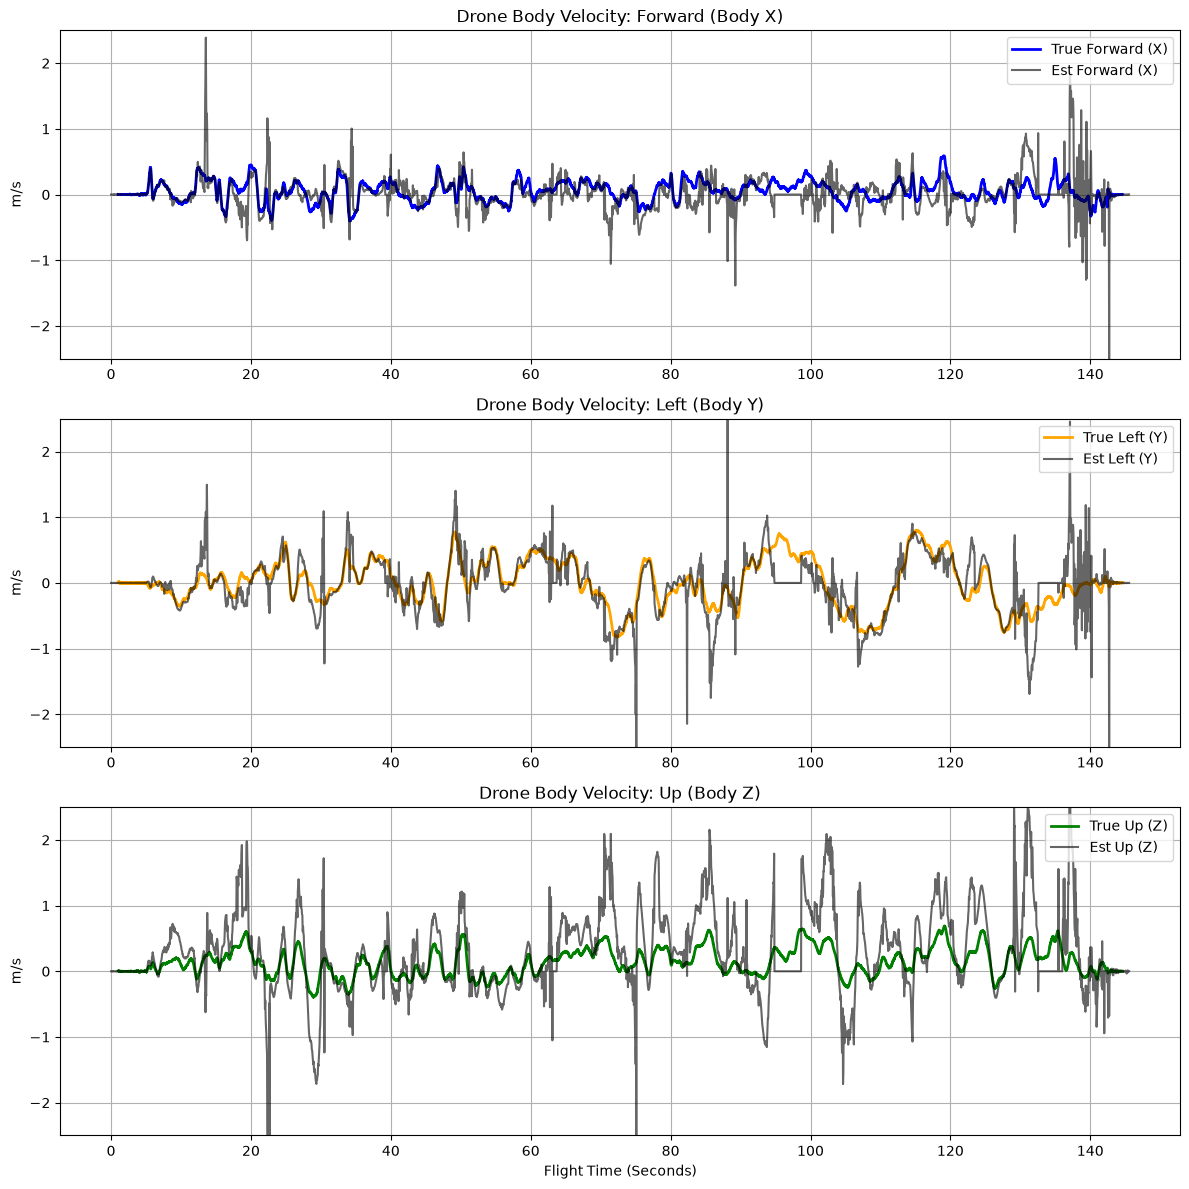

In [29]:
from scipy.spatial.transform import Rotation as R
import numpy as np

# 1. Transform Camera Optical Velocity to Drone Body Velocity
# Camera Z (Forward) = Body Z (Forward)
df_cam0['body_v_z'] = df_cam0['vel_z_ms']   

# Camera X (Right) = Body Y (Right)
df_cam0['body_v_y'] = df_cam0['vel_x_ms']   

# Camera Y (Down) = -Body X (Up)
df_cam0['body_v_x'] = -df_cam0['vel_y_ms']

# 2. Transform Ground Truth Global Velocity to Drone Body Velocity
# Extract quaternions (qx, qy, qz, qw) - note scipy expects scalar last
gt_quats = df_gt[['q_x', 'q_y', 'q_z', 'q_w']].values
gt_global_vels = df_gt[['v_x', 'v_y', 'v_z']].values

# Create rotation objects (World to Body means we invert the Body to World quaternions)
rotations = R.from_quat(gt_quats).inv()

# Apply the rotation to the global velocity vectors
gt_body_vels = rotations.apply(gt_global_vels)

df_gt['body_v_x'] = gt_body_vels[:, 0]
df_gt['body_v_y'] = gt_body_vels[:, 1]
df_gt['body_v_z'] = gt_body_vels[:, 2]

# 3. Aligned Plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
axis_labels = ['Forward (X)', 'Left (Y)', 'Up (Z)']
colors = ['blue', 'orange', 'green']

for i, axis in enumerate(['body_v_x', 'body_v_y', 'body_v_z']):
    # Ground Truth Body Velocity
    axes[i].plot(time_gt, df_gt[axis], label=f'True {axis_labels[i]}', color=colors[i], linewidth=2)
    
    # Camera Body Velocity
    axes[i].plot(time_cam, df_cam0[axis], label=f'Est {axis_labels[i]}', color='black', alpha=0.6)
    
    axes[i].set_title(f"Local Drone Body Velocity: {axis_labels[i]}")
    axes[i].set_ylabel("m/s")
    axes[i].set_ylim([-2.5, 2.5])
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

axes[2].set_xlabel("Flight Time (Seconds)")
plt.tight_layout()
plt.show()

In [21]:
def generate_3d_kinematic_signal(df_cam0, df_cam1, base_path):
    print("Initializing Bucketed & Sub-Pixel 3D Stereo Optical Flow...")
    K, D, BASELINE, fx, fy, cx, cy = load_camera_calibration(base_path)
    
    klt_params = dict(winSize=KLT_WIN_SIZE, maxLevel=KLT_MAX_LEVEL, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
    stereo_params = dict(winSize=STEREO_WIN_SIZE, maxLevel=STEREO_MAX_LEVEL, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))

    cam0_files = df_cam0['filename'].astype(str).values
    cam1_files = df_cam1['filename'].astype(str).values
    dir0 = os.path.join(base_path, "cam0", "data")
    dir1 = os.path.join(base_path, "cam1", "data")
    
    # NEW: Added angular velocity lists
    vel_x, vel_y, vel_z = [0.0], [0.0], [0.0]
    ang_x, ang_y, ang_z = [0.0], [0.0], [0.0] 
    
    old_gray0 = cv2.imread(os.path.join(dir0, cam0_files[0]), cv2.IMREAD_GRAYSCALE)
    p0 = get_bucketed_features(old_gray0, GRID_X, GRID_Y, MAX_PER_BUCKET, QUALITY_LEVEL, MIN_DISTANCE)

    for i in tqdm(range(1, len(cam0_files))):
        frame_gray0 = cv2.imread(os.path.join(dir0, cam0_files[i]), cv2.IMREAD_GRAYSCALE)
        old_gray1 = cv2.imread(os.path.join(dir1, cam1_files[i-1]), cv2.IMREAD_GRAYSCALE)
        
        if frame_gray0 is None or old_gray1 is None or p0 is None:
            vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
            ang_x.append(0.0); ang_y.append(0.0); ang_z.append(0.0)
            continue
            
        p1, st_temp, _ = cv2.calcOpticalFlowPyrLK(old_gray0, frame_gray0, p0, None, **klt_params)
        p0_right, st_stereo, _ = cv2.calcOpticalFlowPyrLK(old_gray0, old_gray1, p0, None, **stereo_params)
        p0_left_check, _, _ = cv2.calcOpticalFlowPyrLK(old_gray1, old_gray0, p0_right, None, **stereo_params)
        
        fb_err = np.linalg.norm(p0 - p0_left_check, axis=2).flatten()
        valid_tracks = (st_temp.flatten() == 1) & (st_stereo.flatten() == 1) & (fb_err < 1.0)
        
        if np.sum(valid_tracks) > 10:
            pts0 = p0[valid_tracks]
            pts0_right = p0_right[valid_tracks]
            pts1 = p1[valid_tracks]
            
            pts0_un = cv2.undistortPoints(pts0, K, D, P=K).reshape(-1, 2)
            pts0_right_un = cv2.undistortPoints(pts0_right, K, D, P=K).reshape(-1, 2)
            pts1_un = cv2.undistortPoints(pts1, K, D, P=K).reshape(-1, 2)
            
            disparity = pts0_un[:, 0] - pts0_right_un[:, 0]
            valid_depth = (disparity > 1.0) & (disparity < 100.0) 
            pts0_un = pts0_un[valid_depth]
            pts1_un = pts1_un[valid_depth]
            disparity = disparity[valid_depth]
            
            if len(pts0_un) > 6:
                Z = (fx * BASELINE) / disparity
                X = (pts0_un[:, 0] - cx) * Z / fx
                Y = (pts0_un[:, 1] - cy) * Z / fy
                points_3d = np.column_stack((X, Y, Z))
                
                try:
                    success, rvec, tvec, inliers = cv2.solvePnPRansac(
                        points_3d, pts1_un, K, np.zeros((4,1)), 
                        iterationsCount=RANSAC_ITERATIONS, 
                        reprojectionError=RANSAC_REPROJ_ERR, 
                        flags=cv2.SOLVEPNP_ITERATIVE
                    )
                    
                    if success and inliers is not None and len(inliers) > 5:
                        R_mat, _ = cv2.Rodrigues(rvec)
                        cam_vel = -np.dot(R_mat.T, tvec)
                        
                        # NEW: Extract Camera Angular Velocity (invert because PnP gives world-to-cam)
                        cam_omega = -rvec
                        
                        vel_x.append(cam_vel[0][0])
                        vel_y.append(cam_vel[1][0])
                        vel_z.append(cam_vel[2][0])
                        
                        ang_x.append(cam_omega[0][0])
                        ang_y.append(cam_omega[1][0])
                        ang_z.append(cam_omega[2][0])
                    else:
                        vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
                        ang_x.append(0.0); ang_y.append(0.0); ang_z.append(0.0)
                except Exception:
                    vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
                    ang_x.append(0.0); ang_y.append(0.0); ang_z.append(0.0)
            else:
                vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
                ang_x.append(0.0); ang_y.append(0.0); ang_z.append(0.0)
        else:
            vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
            ang_x.append(0.0); ang_y.append(0.0); ang_z.append(0.0)
            
        old_gray0 = frame_gray0.copy()
        
        if p1 is None or np.sum(valid_tracks) < 80:
            p0 = get_bucketed_features(old_gray0, GRID_X, GRID_Y, MAX_PER_BUCKET, QUALITY_LEVEL, MIN_DISTANCE)
        else:
            p0 = pts1.reshape(-1, 1, 2)

    df_cam0['vel_x'] = vel_x; df_cam0['vel_y'] = vel_y; df_cam0['vel_z'] = vel_z
    df_cam0['ang_x'] = ang_x; df_cam0['ang_y'] = ang_y; df_cam0['ang_z'] = ang_z
    
    print("Robust 3D Kinematic Extraction Complete!")
    return df_cam0

# Re-run the extraction
df_3d_signal = generate_3d_kinematic_signal(df_cam0, df_cam1, DATASET_PATH)

Initializing Bucketed & Sub-Pixel 3D Stereo Optical Flow...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2911/2911 [00:21<00:00, 134.14it/s]

Robust 3D Kinematic Extraction Complete!


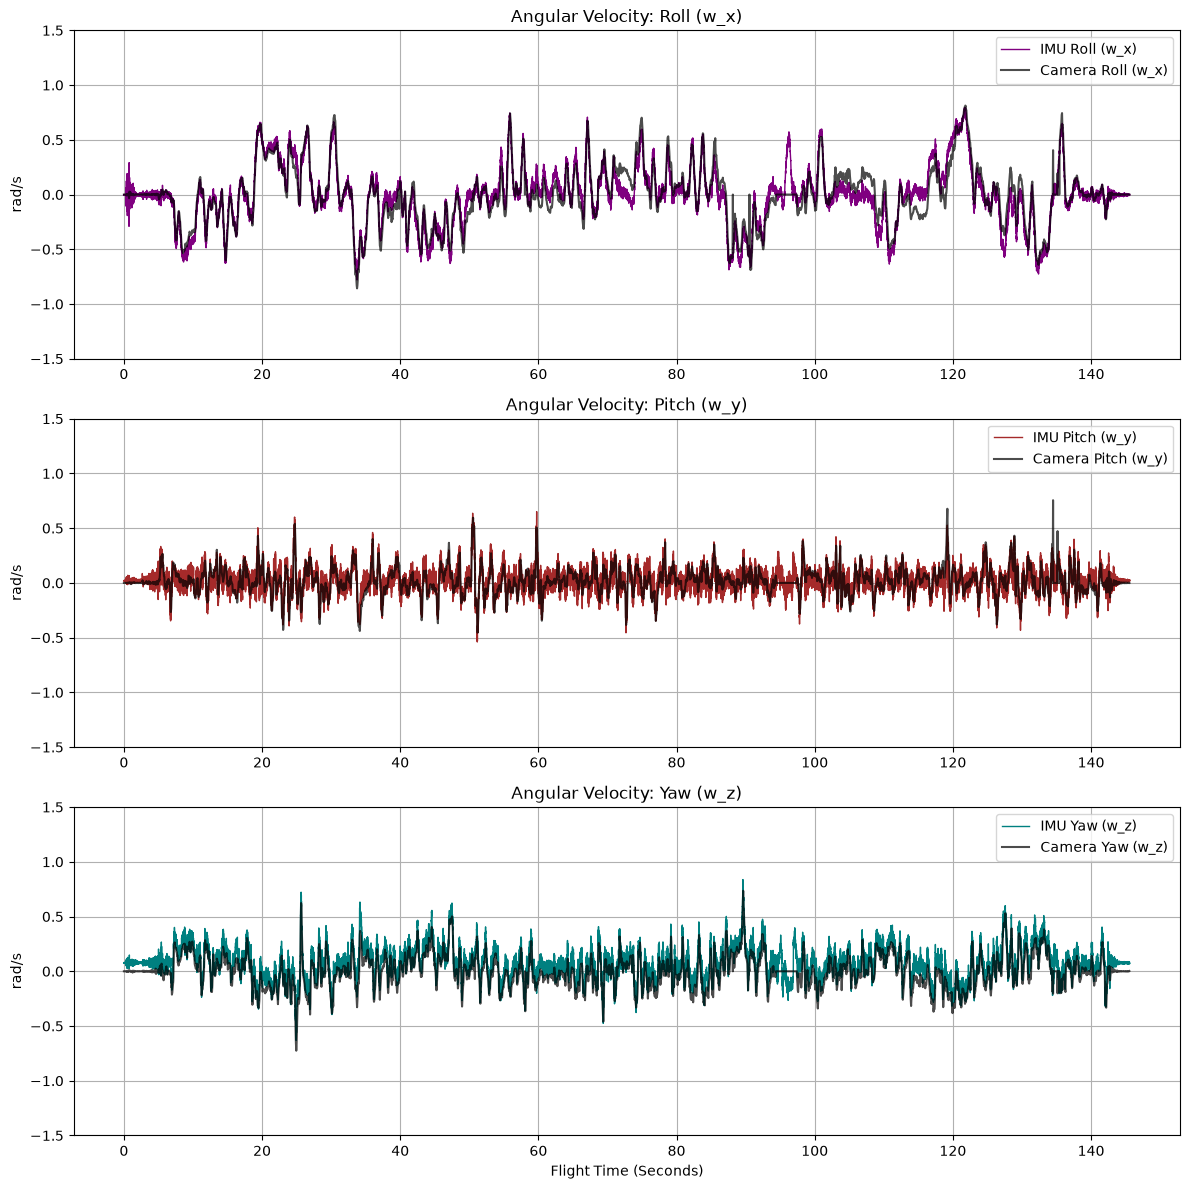

In [23]:
# Convert radians/frame to radians/second
df_cam0['ang_x_rads'] = df_cam0['ang_x'] * 20.0
df_cam0['ang_y_rads'] = df_cam0['ang_y'] * 20.0
df_cam0['ang_z_rads'] = df_cam0['ang_z'] * 20.0

# Map Camera Optical Frame to Drone Body Frame
# Camera Z (Forward) = Body Z (Forward) -> ROLL
df_cam0['body_w_z'] = df_cam0['ang_z_rads']  

# Camera X (Right) = Body Y (Right) -> PITCH
df_cam0['body_w_y'] = df_cam0['ang_x_rads']  

# Camera Y (Down) = -Body X (Up) -> YAW
df_cam0['body_w_x'] = -df_cam0['ang_y_rads']

# Create the time array for the IMU
start_time = df_cam0['timestamp'].iloc[0]
time_imu = (df_imu['timestamp'] - start_time) / 1e9
time_cam = (df_cam0['timestamp'] - start_time) / 1e9

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
axis_labels = ['Roll (w_x)', 'Pitch (w_y)', 'Yaw (w_z)']
colors = ['purple', 'brown', 'teal']

for i, axis in enumerate(['w_x', 'w_y', 'w_z']):
    # Plot 200Hz True IMU Angular Velocity
    axes[i].plot(time_imu, df_imu[axis], label=f'IMU {axis_labels[i]}', color=colors[i], linewidth=1)
    
    # Plot 20Hz Extracted Camera Angular Velocity
    cam_axis = f'body_{axis}'
    axes[i].plot(time_cam, df_cam0[cam_axis], label=f'Camera {axis_labels[i]}', color='black', alpha=0.7)
    
    axes[i].set_title(f"Angular Velocity: {axis_labels[i]}")
    axes[i].set_ylabel("rad/s")
    axes[i].set_ylim([-1.5, 1.5])
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

axes[2].set_xlabel("Flight Time (Seconds)")
plt.tight_layout()
plt.show()

In [28]:
# 1. Ensure timestamps are sorted for merge_asof
df_cam0 = df_cam0.sort_values('timestamp')
df_imu = df_imu.sort_values('timestamp')

# 2. Synchronize: For every 20Hz camera frame, pull the closest IMU reading
# direction='nearest' matches each camera frame to its immediate IMU counterpart
df_master = pd.merge_asof(
    df_cam0, 
    df_imu, 
    on='timestamp', 
    direction='nearest'
)

# 3. Add Ground Truth (Vicon) by matching the timestamps
df_master = pd.merge_asof(
    df_master,
    df_gt[['timestamp', 'v_x', 'v_y', 'v_z', 'q_w', 'q_x', 'q_y', 'q_z']],
    on='timestamp',
    direction='nearest'
)

print(f"Master Dataset Synchronized! Shape: {df_master.shape}")
print(df_master.head())

Master Dataset Synchronized! Shape: (2912, 35)
             timestamp                 filename   flow_dx   flow_dy     vel_x  \
0  1403715273262142976  1403715273262142976.png  0.000000  0.000000  0.000000   
1  1403715273312143104  1403715273312143104.png  0.021704 -0.000157 -0.000009   
2  1403715273362142976  1403715273362142976.png  0.001046  0.005703 -0.000014   
3  1403715273412143104  1403715273412143104.png  0.000391 -0.010843  0.000051   
4  1403715273462142976  1403715273462142976.png -0.002224  0.005209 -0.000026   

      vel_y     vel_z  vel_x_ms  vel_y_ms  vel_z_ms  ...       a_x       a_y  \
0  0.000000  0.000000  0.000000  0.000000  0.000000  ...  9.087496  0.130755   
1  0.000021  0.000091 -0.000252  0.000682  0.001249  ...  9.087496  0.138928   
2 -0.000024 -0.000013 -0.000124 -0.000834 -0.001041  ...  9.038462  0.098067   
3 -0.000005  0.000120  0.000219  0.000849  0.002021  ...  9.079323  0.089894   
4  0.000006 -0.000047  0.000436 -0.000580 -0.002718  ...  9.079323

### Upgrading to 3D Stereo Visual Velocity (Sparse KLT + PnP RANSAC)
To resolve monocular scale ambiguity, we upgrade our pipeline to a 3D Stereo architecture. To maintain computational efficiency, we avoid dense stereo matching. Instead, we utilize a *Sparse Stereo KLT* approach:

1.  ***Spatial Flow (Depth):*** We use KLT to track features from the Left camera to the Right camera at $t_0$. The horizontal pixel disparity is triangulated into 3D metric coordinates ($X, Y, Z$) using the known baseline and focal length.
2.  ***Temporal Flow (Motion):*** We use KLT to track those same features from the Left camera at $t_0$ to the Left camera at $t_1$.
3.  ***Least Squares Optimization (PnP RANSAC):*** We pass the 3D points and the temporally tracked 2D pixels into `cv2.solvePnPRansac`. This robustly filters out bad tracking tracks (outliers) and calculates the optimal 3D Rotation and Translation vectors of the camera.

*Adaptive Architecture Prep:* All classical thresholds are exposed at the top of the block to prepare for dynamic neural network parameter tuning (Phase 4).

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2911/2911 [00:34<00:00, 83.41it/s]


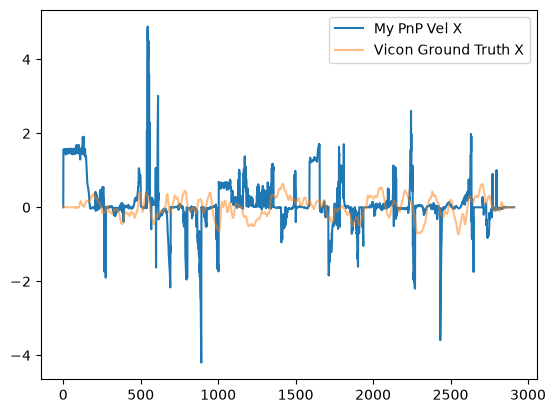

In [109]:
import cv2
import os
import numpy as np

# --- 3D Extraction Hyperparameters ---
# Increased RANSAC iterations for better stability
RANSAC_ITERATIONS = 500 
# Increased reprojection error for more robustness to vibration
RANSAC_REPROJ_ERR = 2.0 

def load_camera_calibration(base_path):
    # Standard EuRoC calibration values
    fx, fy, cx, cy = 458.654, 457.296, 367.215, 248.375
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
    D = np.array([-0.2834, 0.0739, 0.0001, 0.00001], dtype=np.float64)
    baseline = 0.110078 
    return K, D, baseline, fx, fy, cx, cy

def generate_3d_kinematic_signal(df_cam0, df_cam1, base_path):
    K, D, BASELINE, fx, fy, cx, cy = load_camera_calibration(base_path)
    
    lk_params = dict(winSize=(21, 21), maxLevel=3, 
                     criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
    
    vel_x, vel_y, vel_z = [0.0], [0.0], [0.0]
    
    dir0 = os.path.join(base_path, "cam0", "data")
    dir1 = os.path.join(base_path, "cam1", "data")
    
    # Initialize tracking
    old_gray0 = cv2.imread(os.path.join(dir0, df_cam0['filename'].iloc[0]), cv2.IMREAD_GRAYSCALE)
    p0 = cv2.goodFeaturesToTrack(old_gray0, maxCorners=300, qualityLevel=0.1, minDistance=7)
    
    for i in tqdm(range(1, len(df_cam0))):
        frame_gray0 = cv2.imread(os.path.join(dir0, df_cam0['filename'].iloc[i]), cv2.IMREAD_GRAYSCALE)
        old_gray1 = cv2.imread(os.path.join(dir1, df_cam1['filename'].iloc[i-1]), cv2.IMREAD_GRAYSCALE)
        
        if frame_gray0 is None or old_gray1 is None or p0 is None:
            vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
            continue

        # 1. Temporal & Stereo Tracking
        p1, st_temp, _ = cv2.calcOpticalFlowPyrLK(old_gray0, frame_gray0, p0, None, **lk_params)
        p0_right, st_stereo, _ = cv2.calcOpticalFlowPyrLK(old_gray0, old_gray1, p0, None, **lk_params)
        
        valid = (st_temp.flatten() == 1) & (st_stereo.flatten() == 1)
        
        if np.sum(valid) > 30: # Ensure enough points
            # Triangulate
            disparity = p0[valid, 0, 0] - p0_right[valid, 0, 0]
            # Filter out low disparity (invalid depth)
            valid_depth = disparity > 0.5
            
            if np.sum(valid_depth) > 10:
                Z = (fx * BASELINE) / (disparity[valid_depth] + 1e-6)
                X = (p0[valid, 0, 0][valid_depth] - cx) * Z / fx
                Y = (p0[valid, 0, 1][valid_depth] - cy) * Z / fy
                
                points_3d = np.column_stack((X, Y, Z))
                # solvePnPRansac returns success, rvec, tvec, inliers
                success, rvec, tvec, inliers = cv2.solvePnPRansac(
                    points_3d, p1[valid][valid_depth], K, D, 
                    iterationsCount=RANSAC_ITERATIONS, reprojectionError=RANSAC_REPROJ_ERR)
                
                if success and inliers is not None and len(inliers) > 5:
                    R_mat, _ = cv2.Rodrigues(rvec)
                    # Convert to velocity (World-to-Camera)
                    cam_vel = -np.dot(R_mat.T, tvec)
                    vel_x.append(cam_vel[0][0]); vel_y.append(cam_vel[1][0]); vel_z.append(cam_vel[2][0])
                else:
                    vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
            else:
                vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
        else:
            vel_x.append(0.0); vel_y.append(0.0); vel_z.append(0.0)
            
        # Update tracking state
        old_gray0 = frame_gray0.copy()
        # Refresh features if tracking quality degrades
        if p1 is None or np.sum(valid) < 50:
            p0 = cv2.goodFeaturesToTrack(old_gray0, maxCorners=300, qualityLevel=0.1, minDistance=7)
        else:
            p0 = p1
    return vel_x, vel_y, vel_z

# Execute
vx, vy, vz = generate_3d_kinematic_signal(df_cam0, df_cam1, DATASET_PATH)
plt.plot(vx, label='My PnP Vel X')
plt.plot(df_master['v_x'], label='Vicon Ground Truth X', alpha=0.5)
plt.legend()
plt.show()

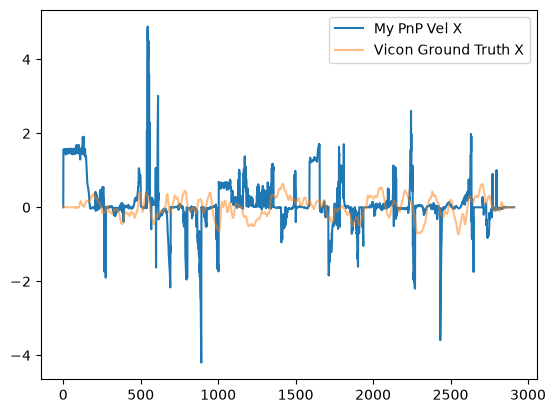

In [108]:
from scipy.signal import savgol_filter

# Apply a Savitzky-Golay filter to smooth the velocity signals
# window_length=11, polyorder=2 are usually great for drone telemetry
vel_x = savgol_filter(vx, 11, 2)
vel_y = savgol_filter(vy, 11, 2)
vel_z = savgol_filter(vz, 11, 2)

# Update the dataframe
df_cam0['vel_x'] = vel_x
df_cam0['vel_y'] = vel_y
df_cam0['vel_z'] = vel_z
plt.plot(vx, label='My PnP Vel X')
plt.plot(df_master['v_x'], label='Vicon Ground Truth X', alpha=0.5)
plt.legend()
plt.show()

### 9-State Error-State Kalman Filter (ESKF) Implementation
We implement an ESKF to serve as the classical baseline for our Visual-Inertial fusion. The filter operates on a **Prediction-Correction** loop:

*   **Prediction (IMU @ 200Hz):** Propagates the drone's pose and velocity using IMU high-frequency accelerations and angular velocities. We maintain an "Error State" vector ($ \delta \mathbf{x} $) representing the discrepancy between the IMU-integrated state and the true state.
*   **Correction (Camera @ 20Hz):** Uses the 3D visual velocity from our KLT pipeline as a measurement update ($ \mathbf{z} $). The Kalman Gain ($ K $) determines how much to trust the camera visual update versus the IMU prediction to "reset" the error state.
*   **State Vector:** $\mathbf{x} = [\mathbf{p}, \mathbf{v}, \boldsymbol{\theta}]^T$, where $\mathbf{p}$ is 3D position, $\mathbf{v}$ is 3D velocity, and $\boldsymbol{\theta}$ is attitude.

In [99]:
from scipy.spatial.transform import Rotation as R

class ESKF:
    def __init__(self, data_subset):
        # 1. Calculate the mean of the first 500 samples (assuming drone is on ground)
        # This is the "Gravity Bias"
        self.gravity_bias = np.mean(data_subset[:500, 0:3], axis=0)
        
        # 2. Use Identity - we'll handle gravity by subtracting the bias
        self.rot = np.eye(3) 
        
        self.p = np.zeros(3)
        self.v = np.zeros(3)
        self.P = np.eye(9) * 0.1
        self.R = np.eye(3) * 0.1

    def predict(self, acc, gyro, dt):
        acc = acc.astype(np.float64)
        gyro = gyro.astype(np.float64)
        self.rot = self.rot @ self.rotation_matrix(gyro * dt)
        acc_corrected = acc - self.gravity_bias
        self.v = self.v + (acc_corrected * dt)
        self.p = self.p + (self.v * dt)

    def update(self, visual_vel):
        """Camera Correction Step (20Hz) using explicit matrix indexing"""
        # 1. Residual: (Measurement - Prediction)
        y = visual_vel - self.v
        
        # 2. Observation Matrix H: Maps 9-state to 3D velocity
        # We only observe velocity, so H is zeros with an Identity at indices 3:6
        H = np.zeros((3, 9))
        H[:, 3:6] = np.eye(3)
        
        # 3. Kalman Gain calculation (Joseph form for stability)
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        
        # 4. Correct the state
        dx = K @ y
        self.p += dx[0:3]
        self.v += dx[3:6]
        
        # 5. Covariance update (Joseph form: (I - KH)P(I - KH)' + KRK')
        I = np.eye(9)
        IKH = I - K @ H
        self.P = IKH @ self.P @ IKH.T + K @ self.R @ K.T

    @staticmethod
    def rotation_matrix(w):
        return np.eye(3) + np.array([[0, -w[2], w[1]], [w[2], 0, -w[0]], [-w[1], w[0], 0]])

Running ESKF Baseline...
Filtering Complete. Trajectory shape: (2912, 3)


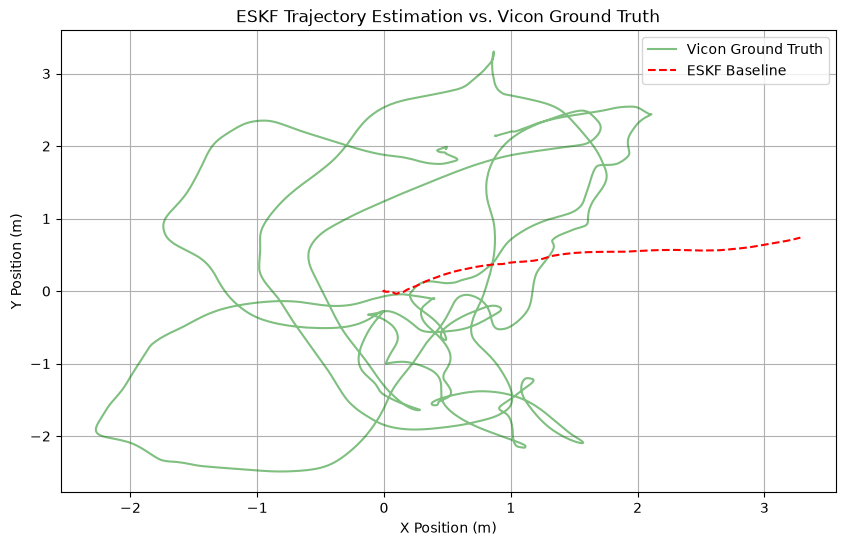

In [100]:
# 1. Clean and prepare data for the filter
# We ensure we have clean float64 arrays to avoid any broadcasting errors
cols = ['a_x', 'a_y', 'a_z', 'w_x', 'w_y', 'w_z', 'body_v_x', 'body_v_y', 'body_v_z']
data = df_master[cols].astype(np.float64).values

# 2. Re-initialize Filter
eskf = ESKF(data)
trajectory = []

# 3. Execution Loop
# We use a fixed dt of 0.005s (1/200Hz) as per EuRoC IMU spec
dt = 0.005 

print("Running ESKF Baseline...")

for i in range(len(data)):
    # --- Prediction (IMU) ---
    acc = data[i, 0:3]
    gyro = data[i, 3:6]
    eskf.predict(data[i, 0:3], data[i, 3:6], dt)
    
    # --- Correction (Camera) ---
    # We check if visual velocity data is available (not NaN/Zero)
    visual_vel = data[i, 6:9]
    # Inside your loop
    if np.any(visual_vel != 0.0): 
        # print("Correction firing!") # Uncomment this to debug
        eskf.update(visual_vel)
        
    # Store the state (position) for plotting
    trajectory.append(eskf.p.copy())

trajectory = np.array(trajectory)
print("Filtering Complete. Trajectory shape:", trajectory.shape)

# 4. Visualization of the ESKF Baseline vs. Vicon Ground Truth
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_gt['p_x'], df_gt['p_y'], label='Vicon Ground Truth', color='green', alpha=0.5)
plt.plot(trajectory[:, 0], trajectory[:, 1], label='ESKF Baseline', color='red', linestyle='--')
plt.title("ESKF Trajectory Estimation vs. Vicon Ground Truth")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()